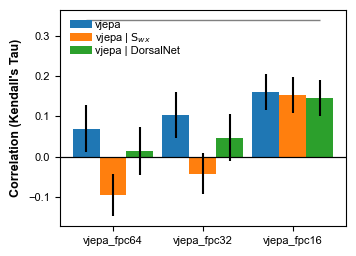

In [7]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import kendalltau, rankdata

from utils.util import compute_noise_ceiling, filter_rsa_data, init_plot


def partial_corr(y, x1, x2, rank_transform=True):
    if rank_transform:
        y = rankdata(y)
        x1 = rankdata(x1)
        x2 = rankdata(x2)

    r_yx1, _ = kendalltau(y, x1)
    r_yx2, _ = kendalltau(y, x2)
    r_x1x2, _ = kendalltau(x1, x2)

    num = r_yx1 - r_yx2 * r_x1x2
    den = np.sqrt((1 - r_yx2**2) * (1 - r_x1x2**2))
    return num / den if den > 0 else 0.0


init_plot()
RDM_folder = "result/model RDM/dynamic"


def load_model(filename, key_filter=None):
    with open(filename, "rb") as f:
        model = pickle.load(f)
    model = {k: v[np.triu_indices(v.shape[0], k=1)] for k, v in model.items()}
    if key_filter:
        filtered_list = filter_rsa_data(model, key_filter)
        indices = [i for i, k in enumerate(model.keys()) if k in filtered_list]
        model = np.array(list(model.values()))[indices, :]
    else:
        model = np.array(list(model.values()))
    return model


slowfast_model = load_model(f"{RDM_folder}/pearson_RDM_slowfast_r50.pkl", "S_wx")
dorsalnet_model = load_model(f"{RDM_folder}/pearson_RDM_dorsalnet.pkl")
vjepa_64_model = load_model(f"{RDM_folder}/pearson_RDM_vjepa_fpc64.pkl")
vjepa_32_model = load_model(f"{RDM_folder}/pearson_RDM_vjepa_fpc32.pkl")
vjepa_16_model = load_model(f"{RDM_folder}/pearson_RDM_vjepa_fpc16.pkl")

fmri_data = []
for sub in range(1, 18):
    if sub in [1, 8]:
        continue
    subject = f"S{sub:02d}"
    with open(f"result/fMRI RDM/pearson/SMG/{subject}_RDM_lh_dynamic.pkl", "rb") as f:
        RDM = pickle.load(f)
    fmri_data.append(RDM[np.triu_indices(RDM.shape[0], k=1)])
fmri_data = np.array(fmri_data)

noise_ceiling, _ = compute_noise_ceiling("SMG", "lh")


def compute_corrs(vjepa_model, fmri_data, l_slowfast, l_dorsal, layer_idx):
    l_vjepa = vjepa_model[layer_idx, :]
    n_subs = len(fmri_data)
    raw_corr = np.zeros(n_subs)
    partial_corrs = np.zeros((n_subs, 2))  # |SlowFast , |DorsalNet
    for i, fmri in enumerate(fmri_data):
        raw_corr[i] = kendalltau(fmri, l_vjepa)[0]
        partial_corrs[i, 0] = partial_corr(fmri, l_vjepa, l_slowfast)
        partial_corrs[i, 1] = partial_corr(fmri, l_vjepa, l_dorsal)
    mean_corr = np.mean(raw_corr)
    sem_corr = stats.sem(raw_corr)
    mean_partial = np.mean(partial_corrs, axis=0)
    sem_partial = stats.sem(partial_corrs, axis=0)
    return mean_corr, sem_corr, mean_partial, sem_partial


l_slowfast = slowfast_model[10, :]
l_dorsal = dorsalnet_model[2, :]

results = {}
results["vjepa_fpc64"] = compute_corrs(
    vjepa_64_model, fmri_data, l_slowfast, l_dorsal, 10
)
results[r"vjepa_fpc32"] = compute_corrs(
    vjepa_32_model, fmri_data, l_slowfast, l_dorsal, 10
)
results[r"vjepa_fpc16"] = compute_corrs(
    vjepa_16_model, fmri_data, l_slowfast, l_dorsal, 15
)

groups = list(results.keys())
n_groups = len(groups)
n_bars = 3  # raw, |SlowFast, |DorsalNet

values = np.zeros((n_groups, n_bars))
errors = np.zeros((n_groups, n_bars))

for i, g in enumerate(groups):
    mean_corr, sem_corr, mean_partial, sem_partial = results[g]
    values[i, 0] = mean_corr
    values[i, 1] = mean_partial[0]
    values[i, 2] = mean_partial[1]
    errors[i, 0] = sem_corr
    errors[i, 1] = sem_partial[0]
    errors[i, 2] = sem_partial[1]

width = 0.3
x = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(3.5, 2.5))
colors = ["tab:blue", "tab:orange", "tab:green"]
labels_bars = ["vjepa", r"vjepa | $\text{S}_{wx}$", "vjepa | DorsalNet"]

for i in range(n_bars):
    ax.bar(
        x + (i - 1) * width,
        values[:, i],
        width,
        yerr=errors[:, i],
        color=colors[i],
        label=labels_bars[i],
    )

# Noise ceiling
ax.hlines(
    noise_ceiling,
    x[0] - width,
    x[-1] + width,
    color="gray",
    linewidth=1,
)

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Correlation (Kendall's Tau)", fontweight="bold")

ax.legend(
    loc="upper left",
    frameon=False,
    labelspacing=0.1,
    handletextpad=0.3,
)
ax.axhline(y=0, color="black", lw=0.8)

plt.tight_layout(pad=0.5)
plt.show()